<a href="https://colab.research.google.com/github/tokiror/maple-scholars-2026/blob/main/Final_Kongwa_DSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Per-month normals (mean TWSA, std):
       mean   std
month            
1      43.3  64.2
2      71.6  87.8
3      84.3  84.9
4      98.7  85.3
5      92.4  82.8
6      63.0  75.4
7      32.4  74.9
8       7.0  67.0
9       0.2  70.3
10     -9.4  63.1
11    -13.9  60.3
12      9.7  60.1
<function categorize at 0x7ce45ee71a80>


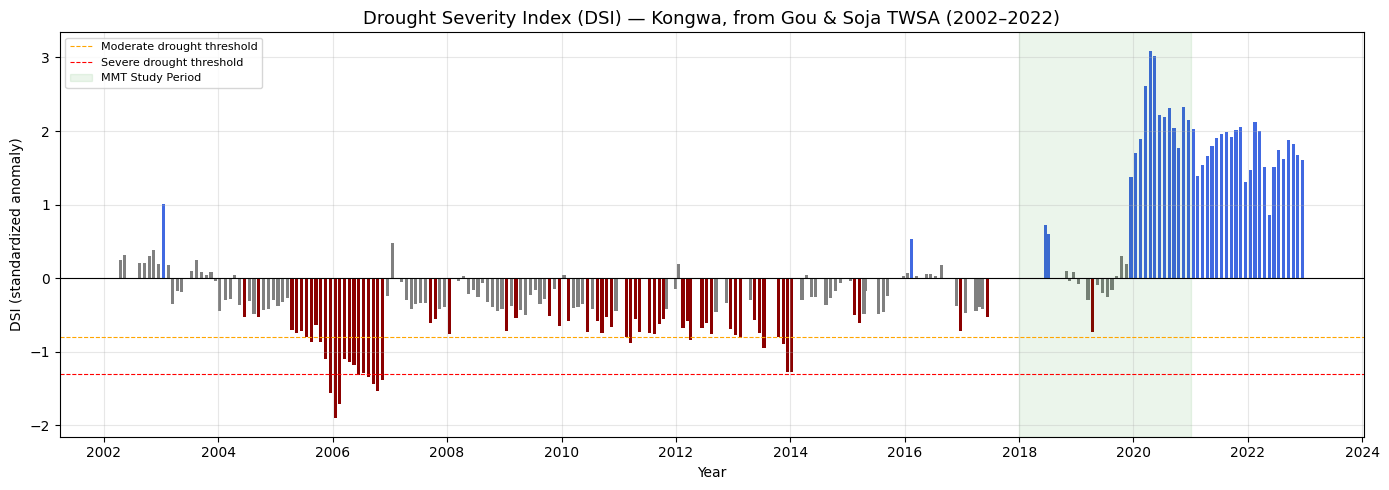


Driest months:
               date  dsi_value    dsi_category
2006-01-16 12:00:00  -1.906122 Extreme drought
2006-02-15 00:00:00  -1.716602 Extreme drought
2005-12-16 12:00:00  -1.556655  Severe drought
2006-10-16 12:00:00  -1.535305  Severe drought
2006-09-16 00:00:00  -1.434807  Severe drought

Wettest months:
               date  dsi_value      dsi_category
2020-04-16 00:00:00   3.092010 Exceptionally wet
2020-05-16 12:00:00   3.018143 Exceptionally wet
2020-03-16 12:00:00   2.612023 Exceptionally wet
2020-11-16 00:00:00   2.323268 Exceptionally wet
2020-08-16 12:00:00   2.316637 Exceptionally wet


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df = pd.read_csv('GouSoja_Kongwa_4pixels.csv')
df['date'] = pd.to_datetime(df['date'])
# Average the 4 pixels into one Kongwa TWSA series
df['kongwa_twsa'] = df[['P1','P2','P3','P4']].mean(axis=1)
df['month'] = df['date'].dt.month
monthly_stats = df.groupby('month')['kongwa_twsa'].agg(['mean','std'])
print("Per-month normals (mean TWSA, std):")
print(monthly_stats.round(1))

#standardized anomaly (z-score) for each month
df['dsi_value'] = df.apply(
    lambda r: (r['kongwa_twsa'] - monthly_stats.loc[r['month'],'mean'])
              / monthly_stats.loc[r['month'],'std'],
    axis=1
)

# Using standard z-score thresholds (US Drought Monitor style)
def categorize(z):
    if pd.isna(z):       return 'No data'
    if z <= -2.0:        return 'Exceptional drought'
    elif z <= -1.6:      return 'Extreme drought'
    elif z <= -1.3:      return 'Severe drought'
    elif z <= -0.8:      return 'Moderate drought'
    elif z <= -0.5:      return 'Abnormally dry'
    elif z <  0.5:       return 'Near normal'
    elif z <  0.8:       return 'Slightly wet'
    elif z <  1.3:       return 'Moderately wet'
    elif z <  1.6:       return 'Very wet'
    elif z <  2.0:       return 'Extremely wet'
    else:                return 'Exceptionally wet'
print(categorize)
df['dsi_category'] = df['dsi_value'].apply(categorize)

# --- Plot the DSI over time ---
fig, ax = plt.subplots(figsize=(14,5))
colors = ['darkred' if v<=-0.5 else 'royalblue' if v>=0.5 else 'gray'
          for v in df['dsi_value']]
ax.bar(df['date'], df['dsi_value'], width=20, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(-0.8, color='orange', ls='--', lw=0.8, label='Moderate drought threshold')
ax.axhline(-1.3, color='red', ls='--', lw=0.8, label='Severe drought threshold')
ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2020-12-31'),
           alpha=0.08, color='green', label='MMT Study Period')
ax.set_title('Drought Severity Index (DSI) — Kongwa, from Gou & Soja TWSA (2002–2022)', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('DSI (standardized anomaly)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('Kongwa_DSI.png', dpi=150)
plt.show()


df[['date','kongwa_twsa','dsi_value','dsi_category']].to_csv('Kongwa_DSI.csv', index=False)
print("\nDriest months:")
print(df.nsmallest(5, 'dsi_value')[['date','dsi_value','dsi_category']].to_string(index=False))
print("\nWettest months:")
print(df.nlargest(5, 'dsi_value')[['date','dsi_value','dsi_category']].to_string(index=False))